<a href="https://colab.research.google.com/github/douglas-varjao/TechChallenge-Fase3-AtrasosVoos/blob/main/Tc3_Analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Análise e Predição de Atrasos de Voos — EUA 2015
### Versão 2.0

---

**Objetivo do projeto:** explorar, compreender e modelar os padrões de atraso no sistema aéreo americano, utilizando um conjunto de dados públicos com informações detalhadas sobre os ~5,8 milhões de voos realizados em 2015.

A análise está estruturada em cinco grandes etapas:

| Etapa | Descrição |
|---|---|
| 1 | Carregamento e dicionário de dados |
| 2 | Análise exploratória (EDA) |
| 3 | Perguntas de negócio |
| 4 | Análise de causas de atraso |
| 5 | Modelagem preditiva (classificação e regressão) |

> **Critério FAA:** um voo é considerado *oficialmente atrasado* quando o atraso na chegada supera **15 minutos**. Pequenas variações de 1–14 min são consideradas normais dentro da operação aérea.


## 1. Configuração do Ambiente

Importação das bibliotecas e definição das constantes visuais utilizadas em todo o projeto.


In [ ]:
# ── Bibliotecas principais ──────────────────────────────────────────────────
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 50)

# ── Paleta de cores consistente ──────────────────────────────────────────────
COR_PRINCIPAL = '#2E86AB'   # azul — informação neutra
COR_ALERTA    = '#E84855'   # vermelho — atraso / ruim
COR_OK        = '#3BB273'   # verde — adiantado / bom
COR_NEUTRO    = '#F4A261'   # laranja — atenção
CMAP_DIV      = 'RdYlGn_r'

# ── Montar o Google Drive ────────────────────────────────────────────────────
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carregamento e Dicionário de Dados

### Três datasets complementares

| Dataset | Descrição | Linhas aprox. |
|---|---|---|
| `flights.csv` | Registro detalhado de cada voo — **dataset principal** | ~5,8 M |
| `airlines.csv` | Código IATA → nome completo da companhia aérea | 14 |
| `airports.csv` | Código IATA → nome, cidade, estado e coordenadas geográficas | 322 |


In [ ]:
# ── Carregamento ────────────────────────────────────────────────────────────
flights  = pd.read_csv("drive/MyDrive/tc3_content/flights.csv", low_memory=False)
airlines = pd.read_csv("drive/MyDrive/tc3_content/airlines.csv")
airports = pd.read_csv("drive/MyDrive/tc3_content/airports.csv")

print(f"flights  : {flights.shape[0]:>10,} linhas × {flights.shape[1]} colunas")
print(f"airlines : {airlines.shape[0]:>10,} linhas × {airlines.shape[1]} colunas")
print(f"airports : {airports.shape[0]:>10,} linhas × {airports.shape[1]} colunas")


flights  :  5,819,079 linhas × 31 colunas
airlines :         14 linhas × 2 colunas
airports :        322 linhas × 7 colunas


### Dicionário de Dados — `flights.csv`

> As colunas de causa de atraso (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`) contêm `NaN` quando o voo **não apresentou** aquele tipo de atraso — comportamento esperado, preenchido com `0` no pré-processamento.


In [ ]:
# ── Exibir dicionário de dados formatado ────────────────────────────────────
dicionario = pd.DataFrame({
    'Coluna': [
        'YEAR','MONTH','DAY','DAY_OF_WEEK','AIRLINE','FLIGHT_NUMBER',
        'TAIL_NUMBER','ORIGIN_AIRPORT','DESTINATION_AIRPORT',
        'SCHEDULED_DEPARTURE','DEPARTURE_TIME','DEPARTURE_DELAY',
        'TAXI_OUT','WHEELS_OFF','SCHEDULED_TIME','ELAPSED_TIME',
        'AIR_TIME','DISTANCE','WHEELS_ON','TAXI_IN',
        'SCHEDULED_ARRIVAL','ARRIVAL_TIME','ARRIVAL_DELAY',
        'DIVERTED','CANCELLED','CANCELLATION_REASON',
        'AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY',
        'LATE_AIRCRAFT_DELAY','WEATHER_DELAY'
    ],
    'Descrição': [
        'Ano do voo','Mês (1–12)','Dia do mês (1–31)',
        'Dia da semana (1=Seg, 7=Dom)',
        'Código IATA da companhia','Número do voo',
        'Registro da aeronave',
        'Aeroporto de origem (IATA)','Aeroporto de destino (IATA)',
        'Partida programada (HHMM)','Partida real (HHMM)',
        'Atraso na partida (min) — negativo = adiantado',
        'Táxi até decolagem (min)','Horário de decolagem (HHMM)',
        'Tempo programado de voo (min)','Tempo real total de voo (min)',
        'Tempo no ar (min)','Distância origem→destino (milhas)',
        'Horário de toque (HHMM)','Táxi até o portão (min)',
        'Chegada programada (HHMM)','Chegada real (HHMM)',
        'Atraso na chegada (min) ← VARIÁVEL-ALVO PRINCIPAL',
        'Voo desviado (1=sim)','Voo cancelado (1=sim)',
        'Motivo: A=Cia, B=Clima, C=NAS, D=Segurança',
        'Atraso — controle aéreo (min)','Atraso — segurança (min)',
        'Atraso — companhia aérea (min)','Atraso — aeronave anterior (min)',
        'Atraso — clima (min)'
    ],
    'Tipo': [
        'int','int','int','int','cat','int',
        'str','cat','cat',
        'int','int','float',
        'float','int','float','float',
        'float','int','int','float',
        'int','int','float',
        'bin','bin','cat',
        'float','float','float','float','float'
    ],
    'É alvo?': [
        'Não','Não','Não','Não','Não','Não',
        'Não','Não','Não',
        'Não','Não','Não',
        'Não','Não','Não','Não',
        'Não','Não','Não','Não',
        'Não','Não','✅ Sim',
        'Sim','Sim','Sim',
        'Sim','Sim','Sim','Sim','Sim'
    ]
})

display(dicionario.style
        .apply(lambda x: ['background: #fff3cd' if v == '✅ Sim' else '' for v in x], axis=0, subset=['É alvo?'])
        .set_properties(**{'font-size': '12px'}))


,Coluna,Descrição,Tipo,É alvo?
0,YEAR,Ano do voo,int,Não
1,MONTH,Mês (1–12),int,Não
2,DAY,Dia do mês (1–31),int,Não
3,DAY_OF_WEEK,"Dia da semana (1=Seg, 7=Dom)",int,Não
4,AIRLINE,Código IATA da companhia,cat,Não
5,FLIGHT_NUMBER,Número do voo,int,Não
6,TAIL_NUMBER,Registro da aeronave,str,Não
7,ORIGIN_AIRPORT,Aeroporto de origem (IATA),cat,Não
8,DESTINATION_AIRPORT,Aeroporto de destino (IATA),cat,Não
9,SCHEDULED_DEPARTURE,Partida programada (HHMM),int,Não


## 3. Pré-Processamento

### Estratégia de tratamento de nulos

| Coluna | Estratégia | Justificativa |
|---|---|---|
| `cols_motivo` (5 colunas de causa) | Substituir `NaN` → `0` | `NaN` significa ausência do tipo de atraso |
| Demais colunas com nulos | Manter | São voos cancelados/desviados (excluídos depois se necessário) |


In [ ]:
# ── 3.1 Verificação de nulos ────────────────────────────────────────────────
nulos = flights.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_pct = (nulos / len(flights) * 100).round(2)
display(pd.DataFrame({'Nulos': nulos, '% do total': nulos_pct}))


,Nulos,% do total
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [ ]:
# ── 3.2 Colunas de causa de atraso: NaN → 0 ────────────────────────────────
cols_motivo = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
               'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

flights[cols_motivo] = flights[cols_motivo].fillna(0)
print("✅ Nulos nas colunas de motivo preenchidos com 0.")


✅ Nulos nas colunas de motivo preenchidos com 0.


In [ ]:
# ── 3.3 Enriquecer com nome da companhia e dados do aeroporto de origem ────
df_voos = flights.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
df_voos.rename(columns={'AIRLINE_y': 'AIRLINE_NAME', 'AIRLINE_x': 'AIRLINE_CODE'}, inplace=True)

df_voos = df_voos.merge(
    airports[['IATA_CODE', 'CITY', 'STATE', 'LATITUDE', 'LONGITUDE']],
    left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left'
).rename(columns={'CITY': 'ORIGIN_CITY', 'STATE': 'ORIGIN_STATE',
                  'LATITUDE': 'ORIGIN_LAT', 'LONGITUDE': 'ORIGIN_LON'})

# ── Feature engineering: variáveis derivadas ────────────────────────────────
df_voos['HORA']          = (df_voos['SCHEDULED_DEPARTURE'] // 100).clip(0, 23).astype(int)
df_voos['DIFF_ATRASO']   = df_voos['ARRIVAL_DELAY'] - df_voos['DEPARTURE_DELAY']  # tempo recuperado/perdido no ar
df_voos['ATRASADO_FAA']  = (df_voos['ARRIVAL_DELAY'] > 15).astype(int)            # rótulo binário FAA

# Classificar cenários partida x chegada
conds = [
    (df_voos['DEPARTURE_DELAY'] > 0) & (df_voos['ARRIVAL_DELAY'] > 0),
    (df_voos['DEPARTURE_DELAY'] > 0) & (df_voos['ARRIVAL_DELAY'] <= 0),
    (df_voos['DEPARTURE_DELAY'] <= 0) & (df_voos['ARRIVAL_DELAY'] > 0),
    (df_voos['DEPARTURE_DELAY'] <= 0) & (df_voos['ARRIVAL_DELAY'] <= 0),
]
labels_cond = [
    'Atrasou na partida E na chegada',
    'Atrasou na partida mas chegou no prazo',
    'Saiu no prazo mas chegou atrasado',
    'Pontual na partida E na chegada',
]
df_voos['CENARIO'] = np.select(conds, labels_cond, default='Indefinido')

labels_motivos = {
    'AIR_SYSTEM_DELAY'   : 'Sistema Aéreo',
    'SECURITY_DELAY'     : 'Segurança',
    'AIRLINE_DELAY'      : 'Companhia Aérea',
    'LATE_AIRCRAFT_DELAY': 'Aeronave Atrasada',
    'WEATHER_DELAY'      : 'Clima'
}

print(f"✅ Dataset enriquecido: {len(df_voos):,} voos | {df_voos.shape[1]} variáveis")


✅ Dataset enriquecido: 5,819,079 voos | 42 variáveis


## 4. Análise Exploratória (EDA)


In [ ]:
# ── 4.1 Resumo geral dos atrasos ────────────────────────────────────────────
df_validos = df_voos.dropna(subset=['ARRIVAL_DELAY'])

total      = len(df_validos)
atrasados  = (df_validos['ARRIVAL_DELAY'] > 15).sum()   # critério FAA
tolerancia = ((df_validos['ARRIVAL_DELAY'] >= 0) & (df_validos['ARRIVAL_DELAY'] <= 15)).sum()
adiantados = (df_validos['ARRIVAL_DELAY'] < 0).sum()

print('=' * 55)
print('  RESUMO GERAL DOS ATRASOS (critério FAA > 15 min)')
print('=' * 55)
print(f'  Total de voos analisados  : {total:>12,}')
print(f'  Voos atrasados (>15 min)  : {atrasados:>12,}  ({atrasados/total*100:.1f}%)')
print(f'  Na tolerância (0–15 min)  : {tolerancia:>12,}  ({tolerancia/total*100:.1f}%)')
print(f'  Voos adiantados (<0 min)  : {adiantados:>12,}  ({adiantados/total*100:.1f}%)')
print('-' * 55)
print(f'  Atraso médio geral        : {df_validos["ARRIVAL_DELAY"].mean():>11.1f} min')
print(f'  Mediana do atraso         : {df_validos["ARRIVAL_DELAY"].median():>11.1f} min')
print(f'  Atraso máximo registrado  : {df_validos["ARRIVAL_DELAY"].max():>11.0f} min')
print(f'  Atraso mínimo (adiantado) : {df_validos["ARRIVAL_DELAY"].min():>11.0f} min')


  RESUMO GERAL DOS ATRASOS (critério FAA > 15 min)
  Total de voos analisados  :    5,714,008
  Voos atrasados (>15 min)  :    1,023,498  (17.9%)
  Na tolerância (0–15 min)  :    1,189,611  (20.8%)
  Voos adiantados (<0 min)  :    3,500,899  (61.3%)
-------------------------------------------------------
  Atraso médio geral        :         4.4 min
  Mediana do atraso         :        -5.0 min
  Atraso máximo registrado  :        1971 min
  Atraso mínimo (adiantado) :         -87 min


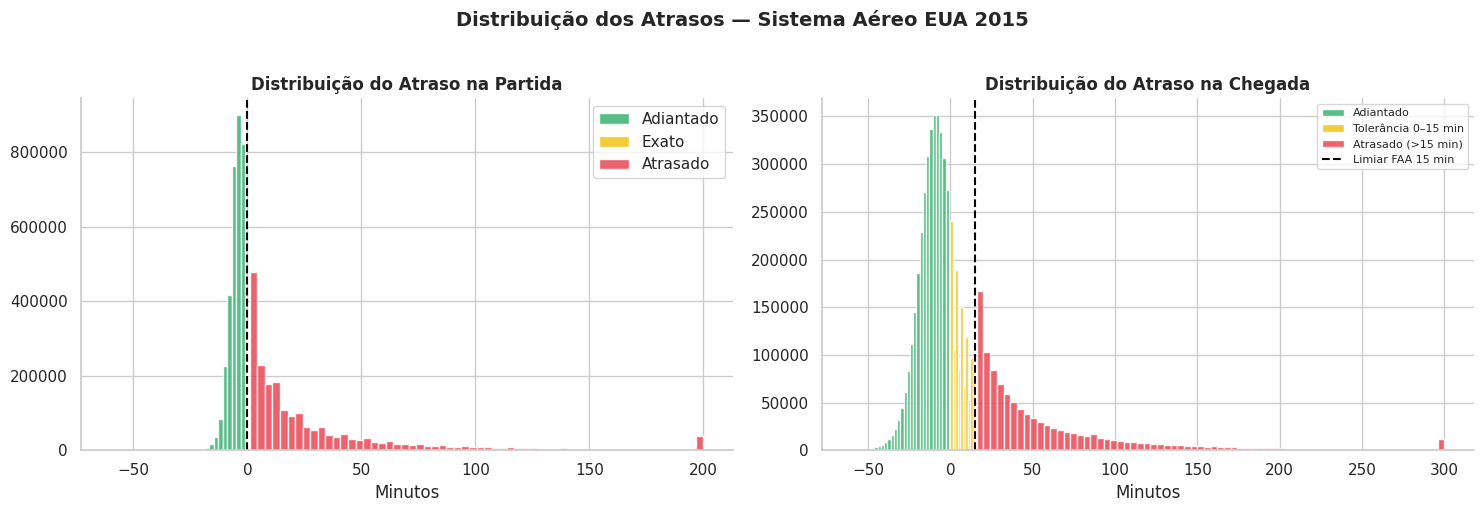

In [ ]:
# ── 4.2 Distribuição: partida vs chegada ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# DEPARTURE_DELAY
dep = df_voos['DEPARTURE_DELAY'].clip(-60, 200).dropna()
axes[0].hist(dep[dep < 0],  bins=30, color=COR_OK,     alpha=0.85, label='Adiantado')
axes[0].hist(dep[dep == 0], bins=5,  color='#F0C419',  alpha=0.85, label='Exato')
axes[0].hist(dep[dep > 0],  bins=60, color=COR_ALERTA, alpha=0.85, label='Atrasado')
axes[0].axvline(0, color='black', linestyle='--', lw=1.5)
axes[0].set_title('Distribuição do Atraso na Partida', fontweight='bold')
axes[0].set_xlabel('Minutos'); axes[0].legend()

# ARRIVAL_DELAY
arr = df_voos['ARRIVAL_DELAY'].clip(-60, 300).dropna()
axes[1].hist(arr[arr < 0],               bins=30, color=COR_OK,     alpha=0.85, label='Adiantado')
axes[1].hist(arr[(arr >= 0) & (arr <= 15)], bins=10, color='#F0C419', alpha=0.85, label='Tolerância 0–15 min')
axes[1].hist(arr[arr > 15],              bins=70, color=COR_ALERTA, alpha=0.85, label='Atrasado (>15 min)')
axes[1].axvline(15, color='black', linestyle='--', lw=1.5, label='Limiar FAA 15 min')
axes[1].set_title('Distribuição do Atraso na Chegada', fontweight='bold')
axes[1].set_xlabel('Minutos'); axes[1].legend(fontsize=8)

plt.suptitle('Distribuição dos Atrasos — Sistema Aéreo EUA 2015', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


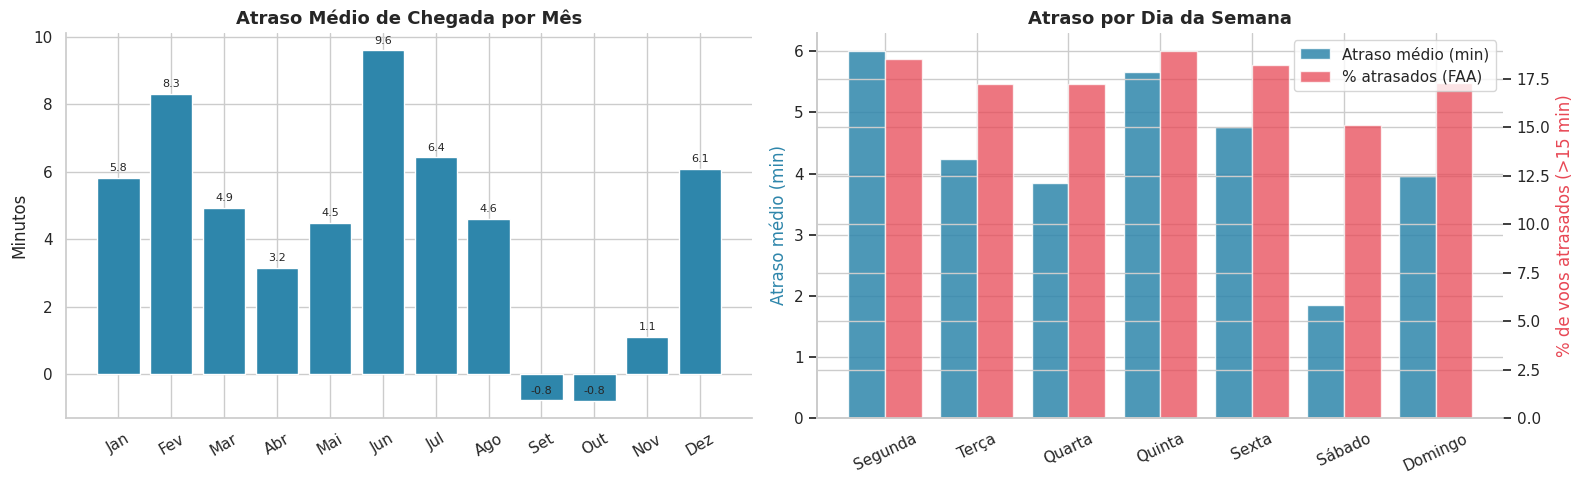

In [ ]:
# ── 4.3 Análise temporal: por mês e por dia da semana ───────────────────────
meses_label = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
dias_label  = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']

por_mes = df_voos.groupby('MONTH').agg(
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    perc_atrasados=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100)
).reset_index()

por_dia = df_voos.groupby('DAY_OF_WEEK').agg(
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    perc_atrasados=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100)
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por mês
cores_mes = [COR_ALERTA if v > 10 else COR_PRINCIPAL for v in por_mes['atraso_medio']]
axes[0].bar(por_mes['MONTH'], por_mes['atraso_medio'], color=cores_mes, edgecolor='white')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(meses_label, rotation=30)
axes[0].set_title('Atraso Médio de Chegada por Mês', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Minutos')
for _, row in por_mes.iterrows():
    axes[0].text(row['MONTH'], row['atraso_medio'] + 0.2, f"{row['atraso_medio']:.1f}", ha='center', fontsize=8)

# Por dia da semana
x = np.arange(len(dias_label)); width = 0.4
ax2 = axes[1].twinx()
axes[1].bar(x - width/2, por_dia['atraso_medio'],   width, color=COR_PRINCIPAL, alpha=0.85, label='Atraso médio (min)')
ax2.bar(x + width/2,     por_dia['perc_atrasados'], width, color=COR_ALERTA,    alpha=0.75, label='% atrasados (FAA)')
axes[1].set_xticks(x); axes[1].set_xticklabels(dias_label, rotation=25)
axes[1].set_ylabel('Atraso médio (min)', color=COR_PRINCIPAL)
ax2.set_ylabel('% de voos atrasados (>15 min)', color=COR_ALERTA)
axes[1].set_title('Atraso por Dia da Semana', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=axes[1].transAxes)

plt.tight_layout(); plt.show()


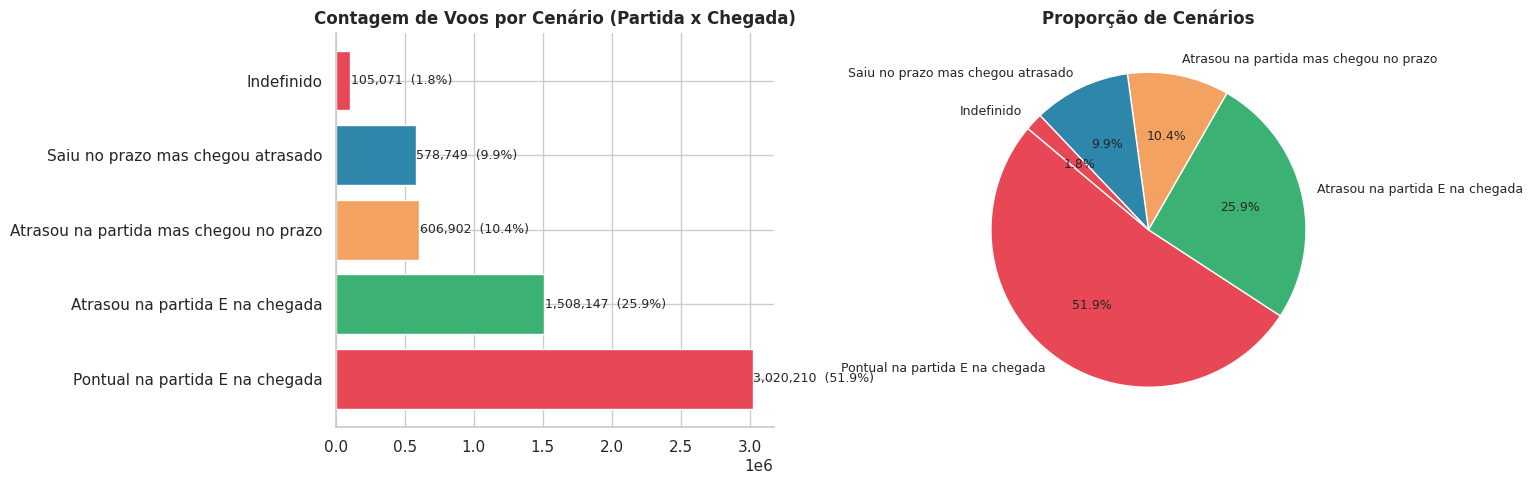

In [ ]:
# ── 4.4 Cenários: partida vs chegada ────────────────────────────────────────
cenarios = df_voos['CENARIO'].value_counts()
cores_cen = [COR_ALERTA, COR_OK, COR_NEUTRO, COR_PRINCIPAL]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(cenarios.index, cenarios.values, color=cores_cen, edgecolor='white')
axes[0].set_title('Contagem de Voos por Cenário (Partida x Chegada)', fontweight='bold')
for i, v in enumerate(cenarios.values):
    axes[0].text(v + 5000, i, f'{v:,}  ({v/len(df_voos)*100:.1f}%)', va='center', fontsize=9)

axes[1].pie(cenarios.values, labels=cenarios.index, colors=cores_cen,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
axes[1].set_title('Proporção de Cenários', fontweight='bold')
plt.tight_layout(); plt.show()


## 5. Perguntas de Negócio

Esta seção responde objetivamente a **15 perguntas analíticas** sobre os dados de atraso.
Cada pergunta apresenta o código necessário e uma conclusão curta.

---


### 📋 Índice das Perguntas

| # | Pergunta |
|---|---|
| Q1 | Qual companhia aérea tem o maior atraso médio na chegada? |
| Q2 | Quais são os 10 aeroportos de origem com maior atraso médio? |
| Q3 | Em qual hora do dia os voos têm mais atraso na partida? |
| Q4 | Qual o principal motivo de atraso no sistema aéreo americano? |
| Q5 | Qual mês do ano tem a maior proporção de voos atrasados? |
| Q6 | Voos mais longos atrasam mais do que voos curtos? |
| Q7 | Quanto do atraso na partida é "recuperado" durante o voo? |
| Q8 | Qual estado americano concentra mais atrasos de chegada? |
| Q9 | Qual rota (par origem–destino) tem o maior atraso médio? |
| Q10 | O atraso de aeronave anterior ("efeito cascata") é o fator mais recorrente? |
| Q11 | Qual companhia cancela mais voos? |
| Q12 | Voos cancelados por clima ocorrem mais em qual mês? |
| Q13 | Existe diferença de atraso entre voos de final de semana e dias úteis? |
| Q14 | Quais companhias conseguem recuperar mais tempo de atraso no ar? |
| Q15 | Como a combinação companhia + dia da semana afeta o atraso? |


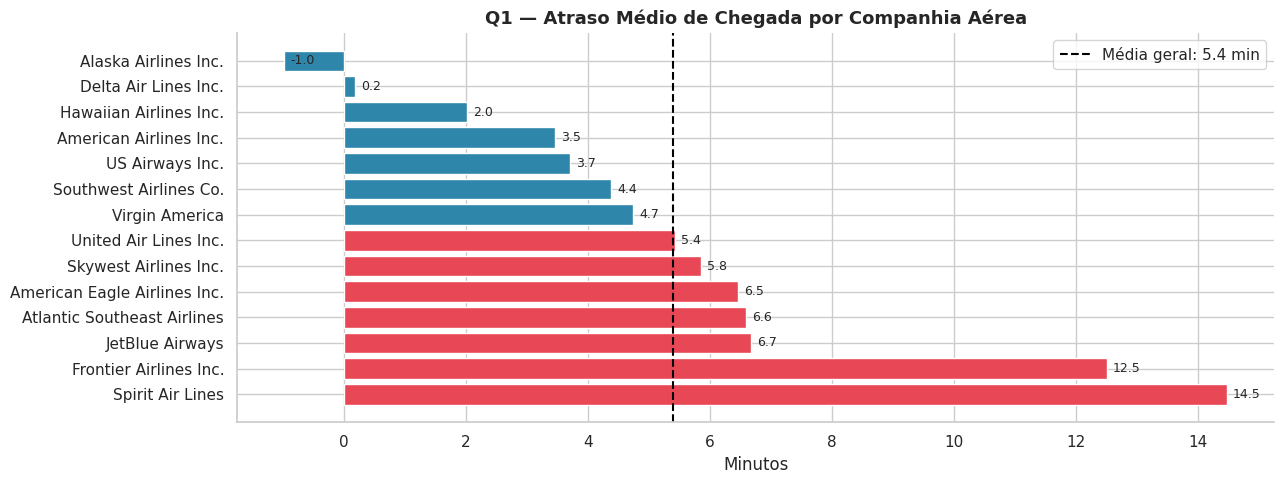


📌 Top 3 mais atrasadas:


,Média (min),Mediana (min),% Atrasados (FAA)
AIRLINE_NAME,,,
Spirit Air Lines,14.5,0.0,28.3%
Frontier Airlines Inc.,12.5,-1.0,25.2%
JetBlue Airways,6.7,-5.0,21.4%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q1 — Qual companhia aérea tem o maior atraso médio na chegada?
# ══════════════════════════════════════════════════════════════════════════════
q1 = (df_voos.groupby('AIRLINE_NAME')['ARRIVAL_DELAY']
      .agg(['mean', 'median', lambda x: (x > 15).mean() * 100])
      .rename(columns={'mean': 'Média (min)', 'median': 'Mediana (min)', '<lambda_0>': '% Atrasados (FAA)'})
      .sort_values('Média (min)', ascending=False))

fig, ax = plt.subplots(figsize=(13, 5))
cores = [COR_ALERTA if v > q1['Média (min)'].mean() else COR_PRINCIPAL for v in q1['Média (min)']]
ax.barh(q1.index, q1['Média (min)'], color=cores, edgecolor='white')
ax.axvline(q1['Média (min)'].mean(), color='black', linestyle='--', lw=1.5, label=f'Média geral: {q1["Média (min)"].mean():.1f} min')
ax.set_title('Q1 — Atraso Médio de Chegada por Companhia Aérea', fontweight='bold', fontsize=13)
ax.set_xlabel('Minutos')
ax.legend()
for i, v in enumerate(q1['Média (min)']):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print("\n📌 Top 3 mais atrasadas:")
display(q1.head(3).style.format({'Média (min)': '{:.1f}', 'Mediana (min)': '{:.1f}', '% Atrasados (FAA)': '{:.1f}%'}))


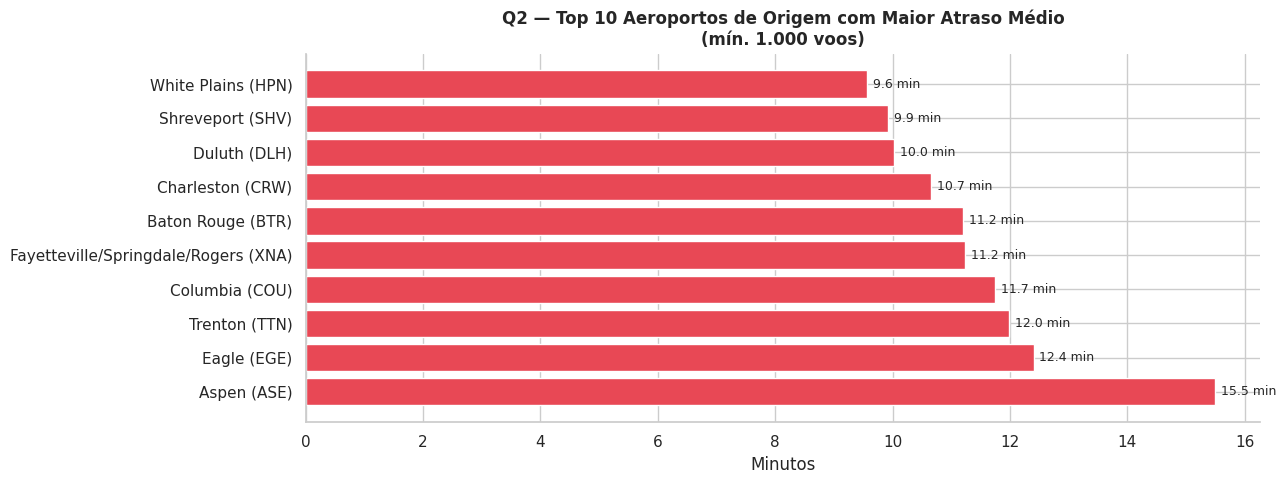

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q2 — Quais são os 10 aeroportos de origem com maior atraso médio?
# ══════════════════════════════════════════════════════════════════════════════
q2 = (df_voos.groupby('ORIGIN_AIRPORT')
      .agg(atraso_medio=('ARRIVAL_DELAY', 'mean'),
           total_voos=('ARRIVAL_DELAY', 'count'))
      .query('total_voos >= 1000')          # mínimo de 1.000 voos para relevância estatística
      .sort_values('atraso_medio', ascending=False)
      .head(10)
      .merge(airports[['IATA_CODE','AIRPORT','CITY','STATE']],
             left_index=True, right_on='IATA_CODE', how='left'))

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(q2['CITY'] + ' (' + q2['IATA_CODE'] + ')', q2['atraso_medio'],
        color=COR_ALERTA, edgecolor='white')
ax.set_title('Q2 — Top 10 Aeroportos de Origem com Maior Atraso Médio\n(mín. 1.000 voos)', fontweight='bold')
ax.set_xlabel('Minutos')
for i, v in enumerate(q2['atraso_medio']):
    ax.text(v + 0.1, i, f'{v:.1f} min', va='center', fontsize=9)
plt.tight_layout(); plt.show()


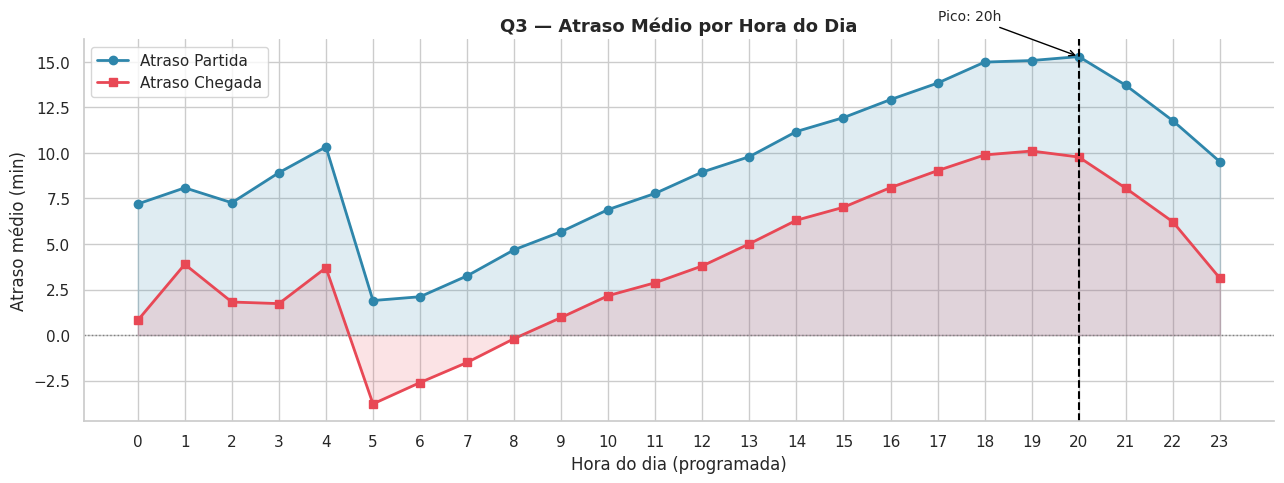


📌 Hora com maior atraso médio na PARTIDA: 20h
   Atraso médio nessa hora: 15.3 min


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q3 — Em qual hora do dia os voos têm mais atraso na partida?
# ══════════════════════════════════════════════════════════════════════════════
q3 = df_voos.groupby('HORA').agg(
    dep_medio=('DEPARTURE_DELAY', 'mean'),
    arr_medio=('ARRIVAL_DELAY', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(q3['HORA'], q3['dep_medio'], marker='o', color=COR_PRINCIPAL, lw=2, label='Atraso Partida')
ax.plot(q3['HORA'], q3['arr_medio'], marker='s', color=COR_ALERTA,    lw=2, label='Atraso Chegada')
ax.axhline(0, color='gray', linestyle=':', lw=1)
ax.fill_between(q3['HORA'], q3['dep_medio'], alpha=0.15, color=COR_PRINCIPAL)
ax.fill_between(q3['HORA'], q3['arr_medio'], alpha=0.15, color=COR_ALERTA)
ax.set_xticks(range(0, 24)); ax.set_xlabel('Hora do dia (programada)')
ax.set_ylabel('Atraso médio (min)')
ax.set_title('Q3 — Atraso Médio por Hora do Dia', fontweight='bold', fontsize=13)
ax.legend()
hora_pico = q3.loc[q3['dep_medio'].idxmax(), 'HORA']
ax.axvline(hora_pico, color='black', linestyle='--', lw=1.5, label=f'Pico: {hora_pico}h')
ax.annotate(f'Pico: {hora_pico}h', xy=(hora_pico, q3['dep_medio'].max()),
            xytext=(hora_pico-3, q3['dep_medio'].max()+2),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.tight_layout(); plt.show()

print(f"\n📌 Hora com maior atraso médio na PARTIDA: {hora_pico}h")
print(f"   Atraso médio nessa hora: {q3.loc[q3['HORA']==hora_pico, 'dep_medio'].values[0]:.1f} min")


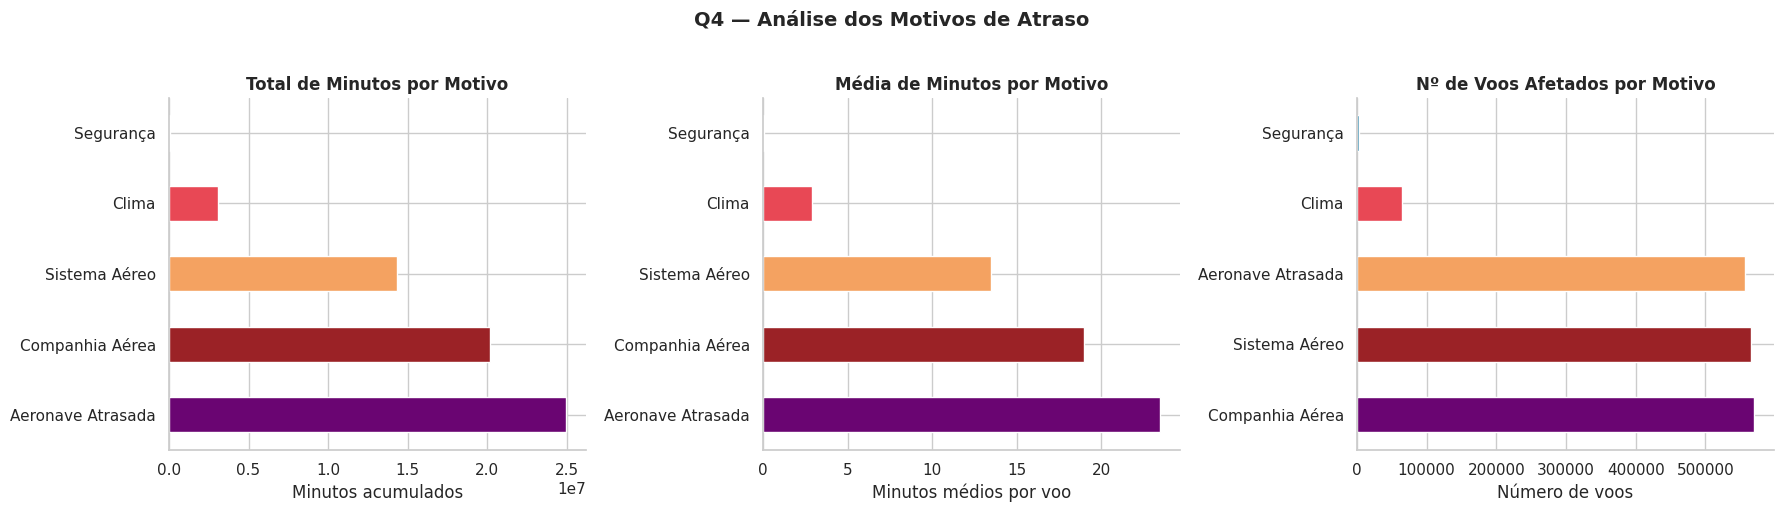


📌 Principal motivo em minutos totais  : Aeronave Atrasada
   Principal motivo em frequência      : Companhia Aérea


In [ ]:
# ═
# Q4 — Qual o principal motivo de atraso no sistema aéreo americano?
# ═
df_com_motivo = df_voos[df_voos[cols_motivo].sum(axis=1) > 0]

total_min   = df_com_motivo[cols_motivo].sum().rename(labels_motivos).sort_values(ascending=False)
media_min   = df_com_motivo[cols_motivo].mean().rename(labels_motivos)
freq_motivo = (df_com_motivo[cols_motivo] > 0).sum().rename(labels_motivos).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = [COR_PRINCIPAL, COR_ALERTA, COR_NEUTRO, '#9B2226', '#6A0572']

total_min.plot(kind='barh', ax=axes[0], color=cores[::-1], edgecolor='white')
axes[0].set_title('Total de Minutos por Motivo', fontweight='bold')
axes[0].set_xlabel('Minutos acumulados')

media_min.rename(labels_motivos).sort_values(ascending=False).plot(kind='barh', ax=axes[1], color=cores[::-1], edgecolor='white')
axes[1].set_title('Média de Minutos por Motivo', fontweight='bold')
axes[1].set_xlabel('Minutos médios por voo')

freq_motivo.plot(kind='barh', ax=axes[2], color=cores[::-1], edgecolor='white')
axes[2].set_title('Nº de Voos Afetados por Motivo', fontweight='bold')
axes[2].set_xlabel('Número de voos')

plt.suptitle('Q4 — Análise dos Motivos de Atraso', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n📌 Principal motivo em minutos totais  : {total_min.index[0]}")
print(f"   Principal motivo em frequência      : {freq_motivo.index[0]}")


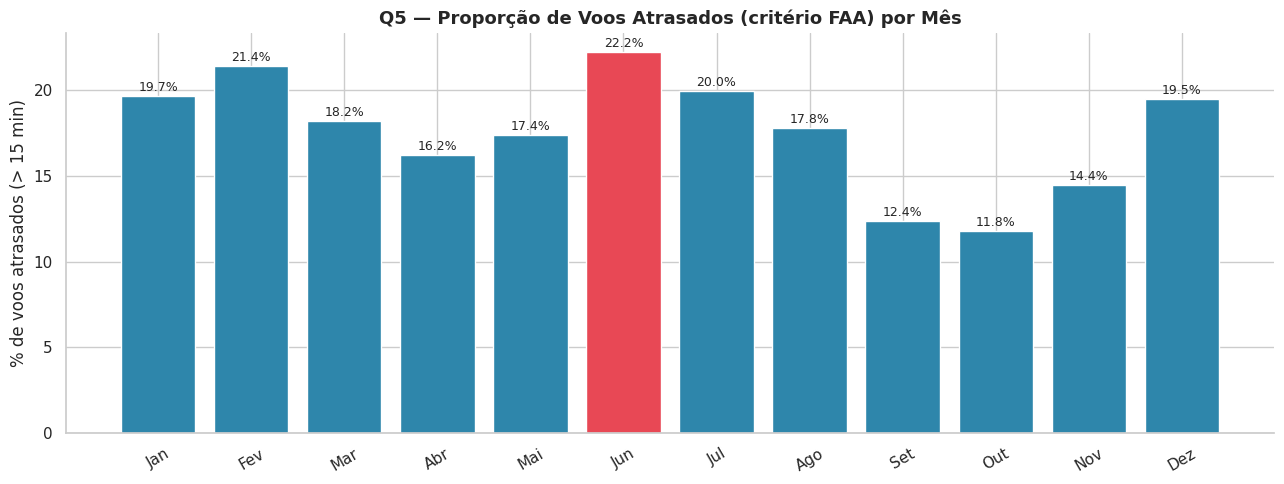


📌 Mês com maior proporção de voos atrasados: Jun
   Proporção: 22.2%


In [ ]:
# ═
# Q5 — Qual mês do ano tem a maior proporção de voos atrasados (FAA)?
# ═
q5 = df_voos.groupby('MONTH').agg(
    perc_atraso_faa=('ATRASADO_FAA', 'mean'),
    atraso_medio=('ARRIVAL_DELAY', 'mean')
).reset_index()
q5['perc_atraso_faa'] *= 100

fig, ax = plt.subplots(figsize=(13, 5))
cores_mes = [COR_ALERTA if v == q5['perc_atraso_faa'].max() else COR_PRINCIPAL for v in q5['perc_atraso_faa']]
bars = ax.bar(q5['MONTH'], q5['perc_atraso_faa'], color=cores_mes, edgecolor='white')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_label, rotation=30)
ax.set_ylabel('% de voos atrasados (> 15 min)')
ax.set_title('Q5 — Proporção de Voos Atrasados (critério FAA) por Mês', fontweight='bold', fontsize=13)
for i, v in enumerate(q5['perc_atraso_faa']):
    ax.text(i + 1, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

mes_pior = meses_label[q5['MONTH'].iloc[q5['perc_atraso_faa'].idxmax()] - 1]
print(f"\n📌 Mês com maior proporção de voos atrasados: {mes_pior}")
print(f"   Proporção: {q5['perc_atraso_faa'].max():.1f}%")


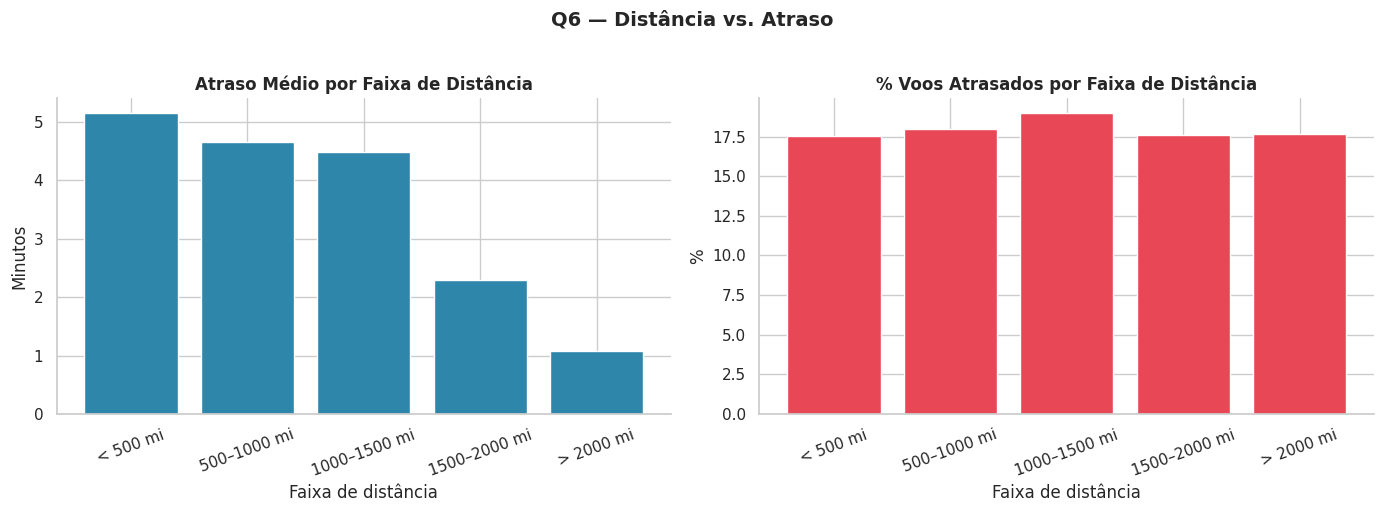

,atraso_medio,perc_atrasado,total
FAIXA_DIST,,,
< 500 mi,5.1 min,17.5%,"2,087,046"
500–1000 mi,4.7 min,18.0%,"2,002,895"
1000–1500 mi,4.5 min,19.0%,"846,699"
1500–2000 mi,2.3 min,17.6%,"407,741"
> 2000 mi,1.1 min,17.7%,"369,627"


In [ ]:
# ═
# Q6 — Voos mais longos atrasam mais do que voos curtos?
# ══
q6 = df_voos.dropna(subset=['DISTANCE','ARRIVAL_DELAY']).copy()
q6['FAIXA_DIST'] = pd.cut(q6['DISTANCE'],
                           bins=[0, 500, 1000, 1500, 2000, 5000],
                           labels=['< 500 mi','500–1000 mi','1000–1500 mi','1500–2000 mi','> 2000 mi'])

q6_grouped = q6.groupby('FAIXA_DIST').agg(
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    perc_atrasado=('ATRASADO_FAA', lambda x: x.mean() * 100),
    total=('ARRIVAL_DELAY', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(q6_grouped['FAIXA_DIST'], q6_grouped['atraso_medio'], color=COR_PRINCIPAL, edgecolor='white')
axes[0].set_title('Atraso Médio por Faixa de Distância', fontweight='bold')
axes[0].set_ylabel('Minutos'); axes[0].set_xlabel('Faixa de distância')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(q6_grouped['FAIXA_DIST'], q6_grouped['perc_atrasado'], color=COR_ALERTA, edgecolor='white')
axes[1].set_title('% Voos Atrasados por Faixa de Distância', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].set_xlabel('Faixa de distância')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Q6 — Distância vs. Atraso', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

display(q6_grouped.set_index('FAIXA_DIST')
        .style.format({'atraso_medio': '{:.1f} min', 'perc_atrasado': '{:.1f}%', 'total': '{:,.0f}'}))


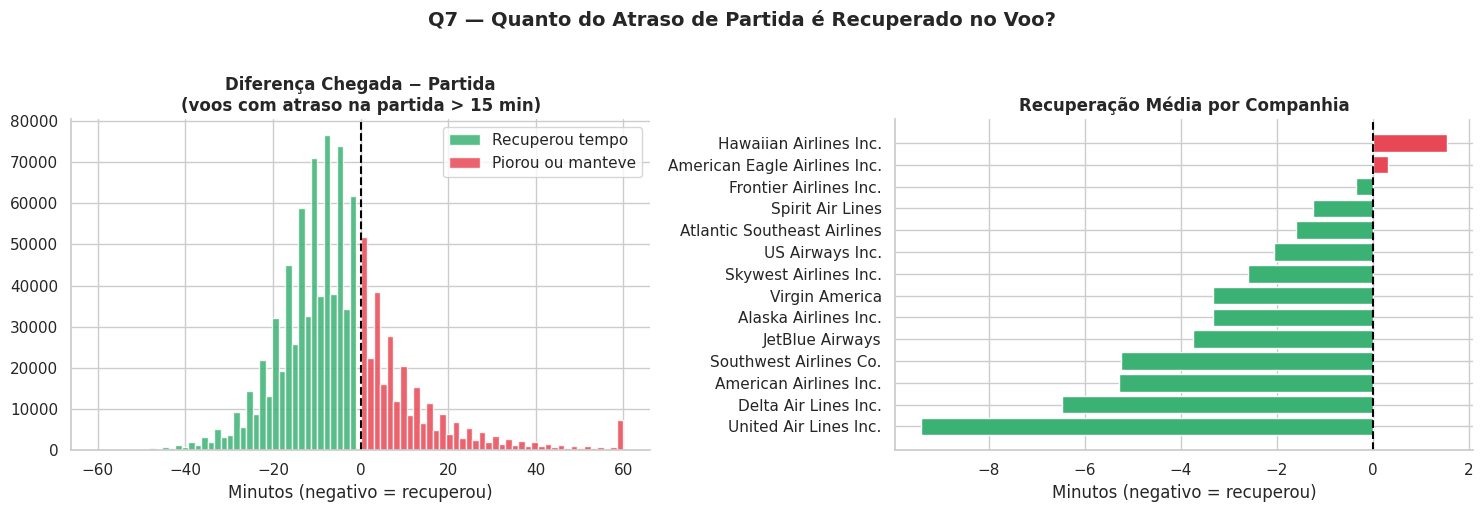


📌 69.8% dos voos atrasados na partida conseguem recuperar tempo no ar.


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q7 — Quanto do atraso na partida é "recuperado" durante o voo?
# ══════════════════════════════════════════════════════════════════════════════
# DIFF_ATRASO = ARRIVAL_DELAY - DEPARTURE_DELAY
# Negativo → recuperou tempo no ar | Positivo → piorou

q7 = df_voos.dropna(subset=['DIFF_ATRASO']).copy()
q7_atrasados = q7[q7['DEPARTURE_DELAY'] > 15]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

diff_clip = q7_atrasados['DIFF_ATRASO'].clip(-60, 60)
axes[0].hist(diff_clip[diff_clip < 0], bins=40, color=COR_OK,     alpha=0.85, label='Recuperou tempo')
axes[0].hist(diff_clip[diff_clip >= 0], bins=40, color=COR_ALERTA, alpha=0.85, label='Piorou ou manteve')
axes[0].axvline(0, color='black', linestyle='--', lw=1.5)
axes[0].set_title('Diferença Chegada − Partida\n(voos com atraso na partida > 15 min)', fontweight='bold')
axes[0].set_xlabel('Minutos (negativo = recuperou)'); axes[0].legend()

q7_por_cia = q7_atrasados.groupby('AIRLINE_NAME')['DIFF_ATRASO'].mean().sort_values()
cores_q7 = [COR_OK if v < 0 else COR_ALERTA for v in q7_por_cia]
axes[1].barh(q7_por_cia.index, q7_por_cia.values, color=cores_q7, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Recuperação Média por Companhia', fontweight='bold')
axes[1].set_xlabel('Minutos (negativo = recuperou)')

plt.suptitle('Q7 — Quanto do Atraso de Partida é Recuperado no Voo?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

pct_recupera = (diff_clip < 0).mean() * 100
print(f"\n📌 {pct_recupera:.1f}% dos voos atrasados na partida conseguem recuperar tempo no ar.")


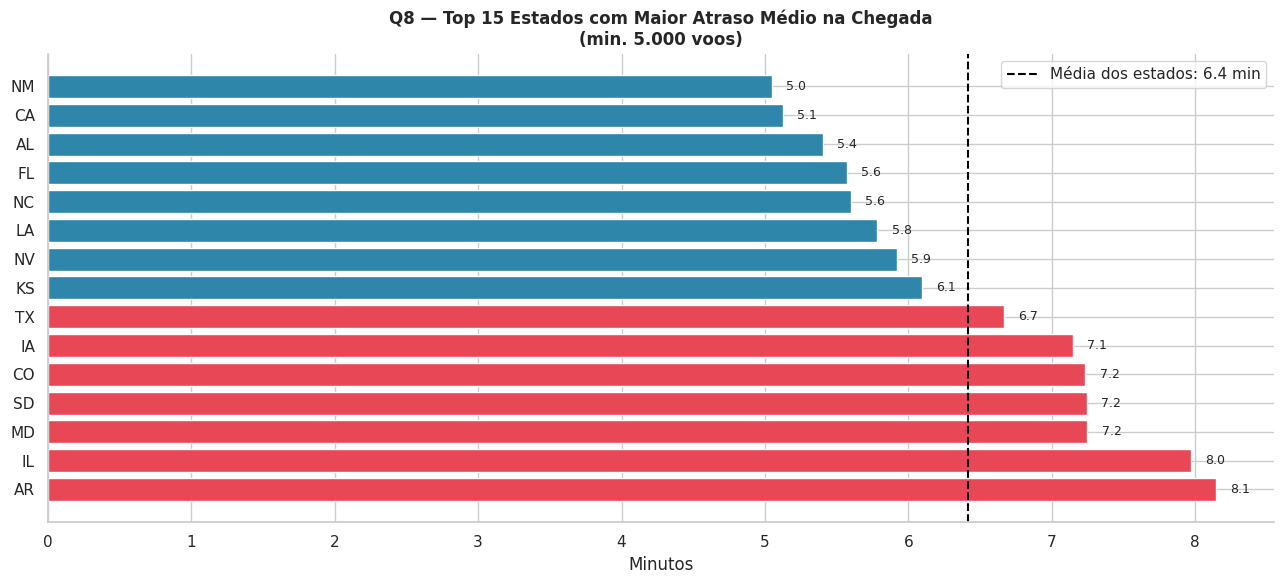

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q8 — Qual estado americano concentra mais atrasos de chegada?
# ══════════════════════════════════════════════════════════════════════════════
q8 = (df_voos.groupby('ORIGIN_STATE').agg(
          atraso_medio=('ARRIVAL_DELAY', 'mean'),
          perc_atrasados=('ATRASADO_FAA', lambda x: x.mean() * 100),
          total_voos=('ARRIVAL_DELAY', 'count'))
      .query('total_voos >= 5000')
      .sort_values('atraso_medio', ascending=False)
      .head(15))

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(q8.index, q8['atraso_medio'],
        color=[COR_ALERTA if v > q8['atraso_medio'].mean() else COR_PRINCIPAL for v in q8['atraso_medio']],
        edgecolor='white')
ax.axvline(q8['atraso_medio'].mean(), color='black', linestyle='--', lw=1.5,
           label=f'Média dos estados: {q8["atraso_medio"].mean():.1f} min')
ax.set_title('Q8 — Top 15 Estados com Maior Atraso Médio na Chegada\n(min. 5.000 voos)', fontweight='bold')
ax.set_xlabel('Minutos'); ax.legend()
for i, v in enumerate(q8['atraso_medio']):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


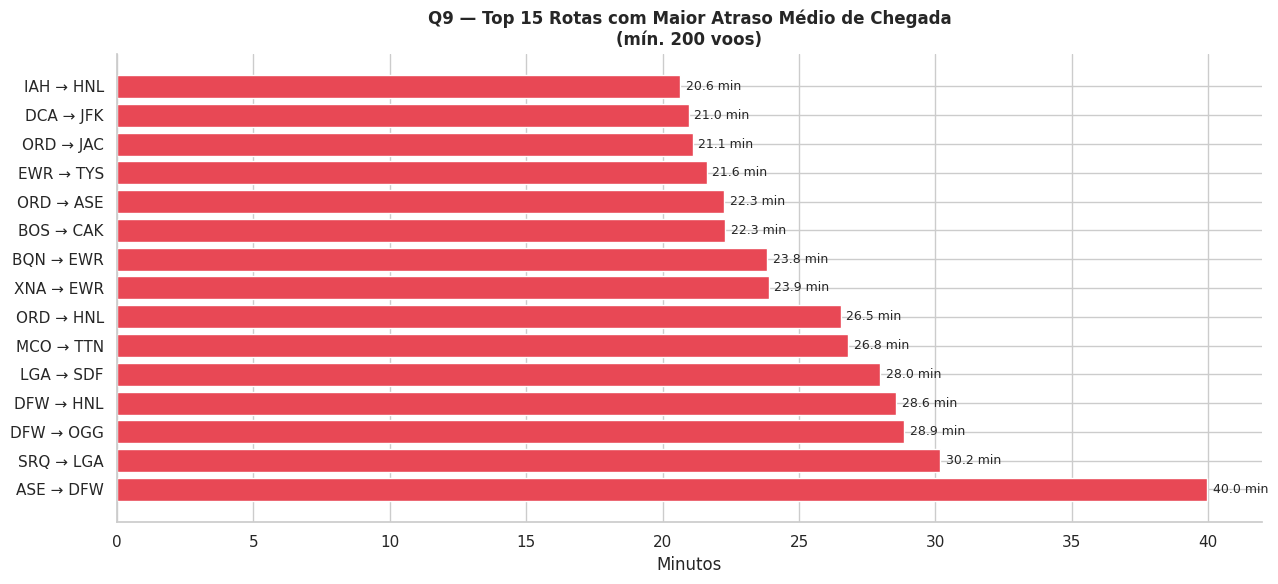


📌 Rota campeã em atraso:


,atraso_medio,total_voos
ROTA,,
ASE → DFW,39.965649,262
SRQ → LGA,30.169048,420
DFW → OGG,28.856566,495


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q9 — Qual rota (par origem–destino) tem o maior atraso médio?
# ══════════════════════════════════════════════════════════════════════════════
q9 = (df_voos.assign(ROTA=df_voos['ORIGIN_AIRPORT'] + ' → ' + df_voos['DESTINATION_AIRPORT'])
      .groupby('ROTA')
      .agg(atraso_medio=('ARRIVAL_DELAY','mean'),
           total_voos=('ARRIVAL_DELAY','count'))
      .query('total_voos >= 200')  # mínimo de 200 voos por rota
      .sort_values('atraso_medio', ascending=False)
      .head(15))

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(q9.index, q9['atraso_medio'], color=COR_ALERTA, edgecolor='white')
ax.set_title('Q9 — Top 15 Rotas com Maior Atraso Médio de Chegada\n(mín. 200 voos)', fontweight='bold')
ax.set_xlabel('Minutos')
for i, v in enumerate(q9['atraso_medio']):
    ax.text(v + 0.2, i, f'{v:.1f} min', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print("\n📌 Rota campeã em atraso:")
display(q9.head(3))


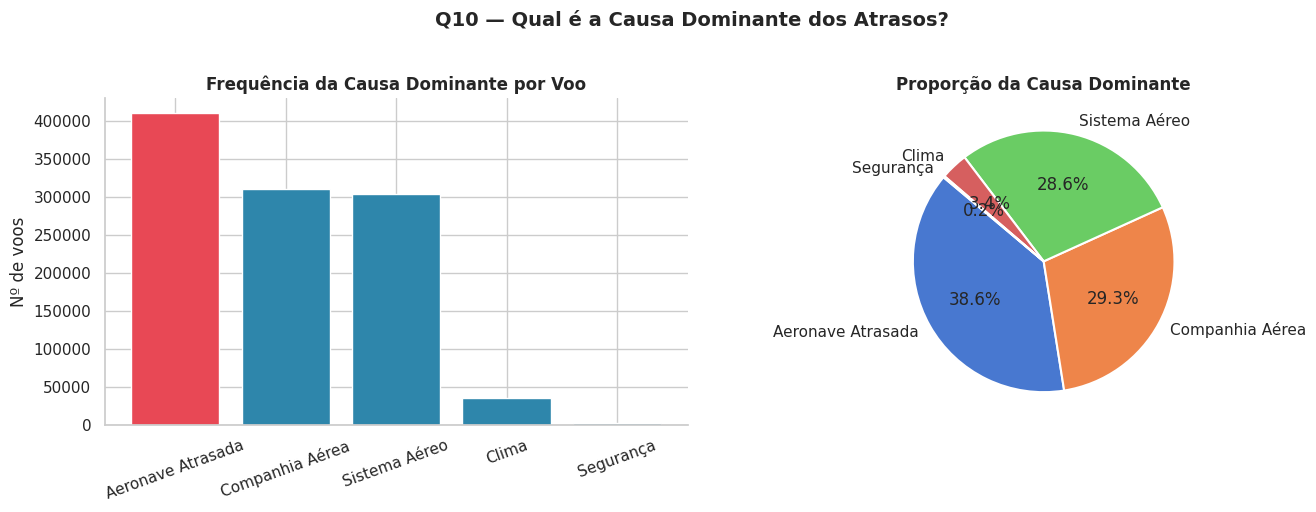


📌 Causa mais frequente: Aeronave Atrasada (38.6%)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q10 — O "efeito cascata" (LATE_AIRCRAFT_DELAY) é o fator mais recorrente?
# ══════════════════════════════════════════════════════════════════════════════
df_m = df_voos[df_voos[cols_motivo].sum(axis=1) > 0]

# Causa dominante em cada voo
df_m = df_m.copy()
df_m['CAUSA_DOMINANTE'] = df_m[cols_motivo].idxmax(axis=1).map(labels_motivos)

contagem  = df_m['CAUSA_DOMINANTE'].value_counts()
proporcao = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(contagem.index, contagem.values,
            color=[COR_ALERTA if i == 0 else COR_PRINCIPAL for i in range(len(contagem))],
            edgecolor='white')
axes[0].set_title('Frequência da Causa Dominante por Voo', fontweight='bold')
axes[0].set_ylabel('Nº de voos')
axes[0].tick_params(axis='x', rotation=20)

wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
axes[1].pie(proporcao.values, labels=proporcao.index, autopct='%1.1f%%',
            startangle=140, wedgeprops=wedge_props)
axes[1].set_title('Proporção da Causa Dominante', fontweight='bold')

plt.suptitle('Q10 — Qual é a Causa Dominante dos Atrasos?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print(f"\n📌 Causa mais frequente: {contagem.index[0]} ({proporcao.values[0]:.1f}%)")


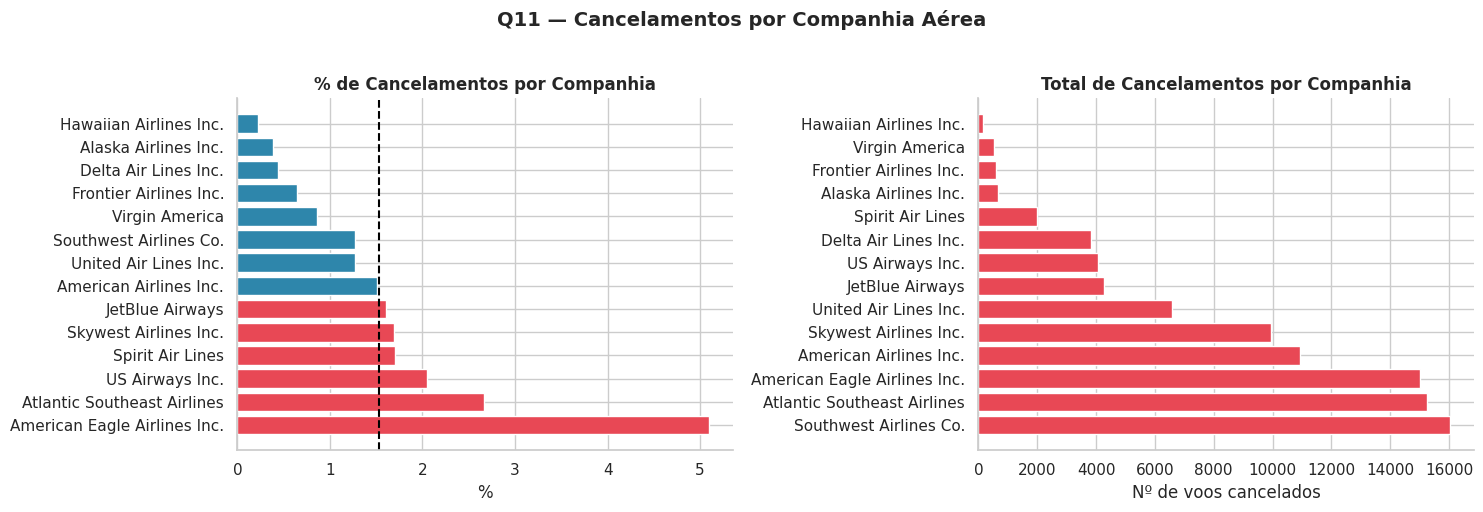

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q11 — Qual companhia cancela mais voos (absoluto e percentual)?
# ══════════════════════════════════════════════════════════════════════════════
q11 = (df_voos.groupby('AIRLINE_NAME')
       .agg(total_voos=('CANCELLED','count'),
            cancelamentos=('CANCELLED','sum'))
       .assign(perc_cancelamento=lambda x: x['cancelamentos'] / x['total_voos'] * 100)
       .sort_values('perc_cancelamento', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cores_q11 = [COR_ALERTA if v > q11['perc_cancelamento'].mean() else COR_PRINCIPAL
             for v in q11['perc_cancelamento']]
axes[0].barh(q11.index, q11['perc_cancelamento'], color=cores_q11, edgecolor='white')
axes[0].axvline(q11['perc_cancelamento'].mean(), color='black', linestyle='--', lw=1.5)
axes[0].set_title('% de Cancelamentos por Companhia', fontweight='bold')
axes[0].set_xlabel('%')

axes[1].barh(q11.sort_values('cancelamentos', ascending=False).index,
             q11.sort_values('cancelamentos', ascending=False)['cancelamentos'],
             color=COR_ALERTA, edgecolor='white')
axes[1].set_title('Total de Cancelamentos por Companhia', fontweight='bold')
axes[1].set_xlabel('Nº de voos cancelados')

plt.suptitle('Q11 — Cancelamentos por Companhia Aérea', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


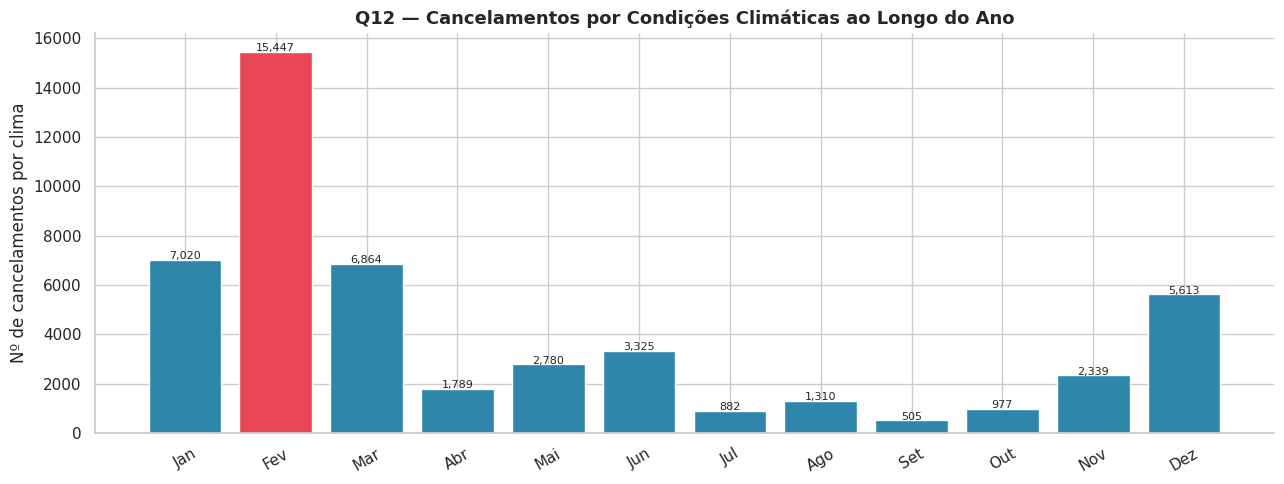


📌 Mês com mais cancelamentos por clima: Fev


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q12 — Cancelamentos por clima (B) são mais frequentes em qual mês?
# ══════════════════════════════════════════════════════════════════════════════
q12 = (df_voos[df_voos['CANCELLATION_REASON'] == 'B']
       .groupby('MONTH').size().reset_index(name='cancelamentos_clima'))

fig, ax = plt.subplots(figsize=(13, 5))
cores_q12 = [COR_ALERTA if v == q12['cancelamentos_clima'].max() else COR_PRINCIPAL
             for v in q12['cancelamentos_clima']]
ax.bar(q12['MONTH'], q12['cancelamentos_clima'], color=cores_q12, edgecolor='white')
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_label, rotation=30)
ax.set_ylabel('Nº de cancelamentos por clima')
ax.set_title('Q12 — Cancelamentos por Condições Climáticas ao Longo do Ano', fontweight='bold', fontsize=13)
for _, row in q12.iterrows():
    ax.text(row['MONTH'], row['cancelamentos_clima'] + 30,
            f"{int(row['cancelamentos_clima']):,}", ha='center', fontsize=8)
plt.tight_layout(); plt.show()

mes_mais_clima = meses_label[q12.loc[q12['cancelamentos_clima'].idxmax(), 'MONTH'] - 1]
print(f"\n📌 Mês com mais cancelamentos por clima: {mes_mais_clima}")


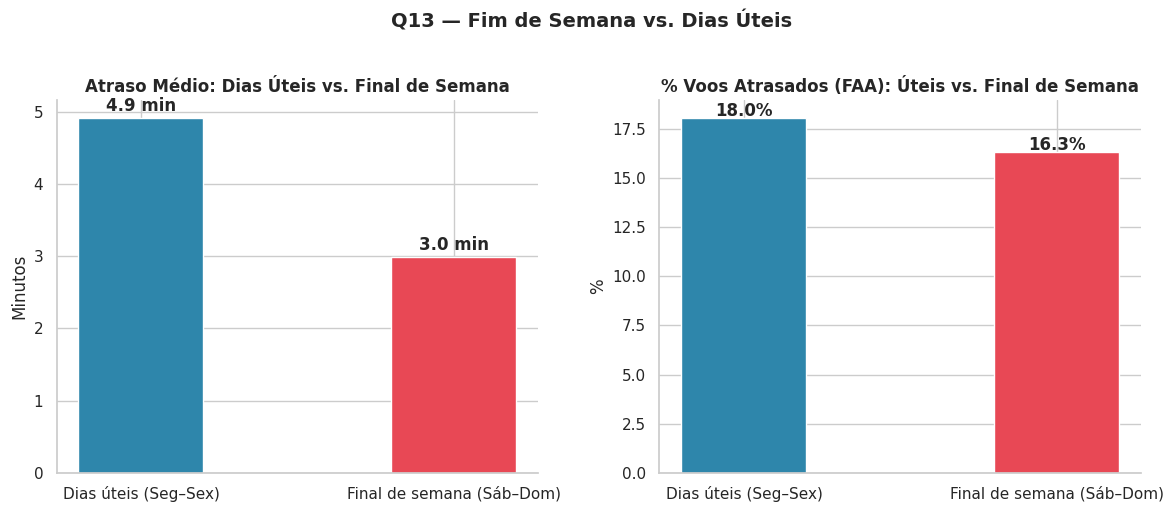

,atraso_medio,perc_atraso_faa,mediana
Dias úteis (Seg–Sex),4.91 min,18.04%,-5.00 min
Final de semana (Sáb–Dom),2.99 min,16.30%,-6.00 min


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q13 — Existe diferença de atraso entre final de semana e dias úteis?
# ══════════════════════════════════════════════════════════════════════════════
df_voos['FIM_SEMANA'] = df_voos['DAY_OF_WEEK'].isin([6, 7])
q13 = df_voos.groupby('FIM_SEMANA').agg(
    atraso_medio=('ARRIVAL_DELAY', 'mean'),
    perc_atraso_faa=('ATRASADO_FAA', lambda x: x.mean() * 100),
    mediana=('ARRIVAL_DELAY', 'median')
)
q13.index = ['Dias úteis (Seg–Sex)', 'Final de semana (Sáb–Dom)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(q13.index, q13['atraso_medio'],
            color=[COR_PRINCIPAL, COR_ALERTA], edgecolor='white', width=0.4)
axes[0].set_title('Atraso Médio: Dias Úteis vs. Final de Semana', fontweight='bold')
axes[0].set_ylabel('Minutos')
for i, v in enumerate(q13['atraso_medio']):
    axes[0].text(i, v + 0.1, f'{v:.1f} min', ha='center', fontweight='bold')

axes[1].bar(q13.index, q13['perc_atraso_faa'],
            color=[COR_PRINCIPAL, COR_ALERTA], edgecolor='white', width=0.4)
axes[1].set_title('% Voos Atrasados (FAA): Úteis vs. Final de Semana', fontweight='bold')
axes[1].set_ylabel('%')
for i, v in enumerate(q13['perc_atraso_faa']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Q13 — Fim de Semana vs. Dias Úteis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

display(q13.style.format({'atraso_medio': '{:.2f} min', 'perc_atraso_faa': '{:.2f}%', 'mediana': '{:.2f} min'}))


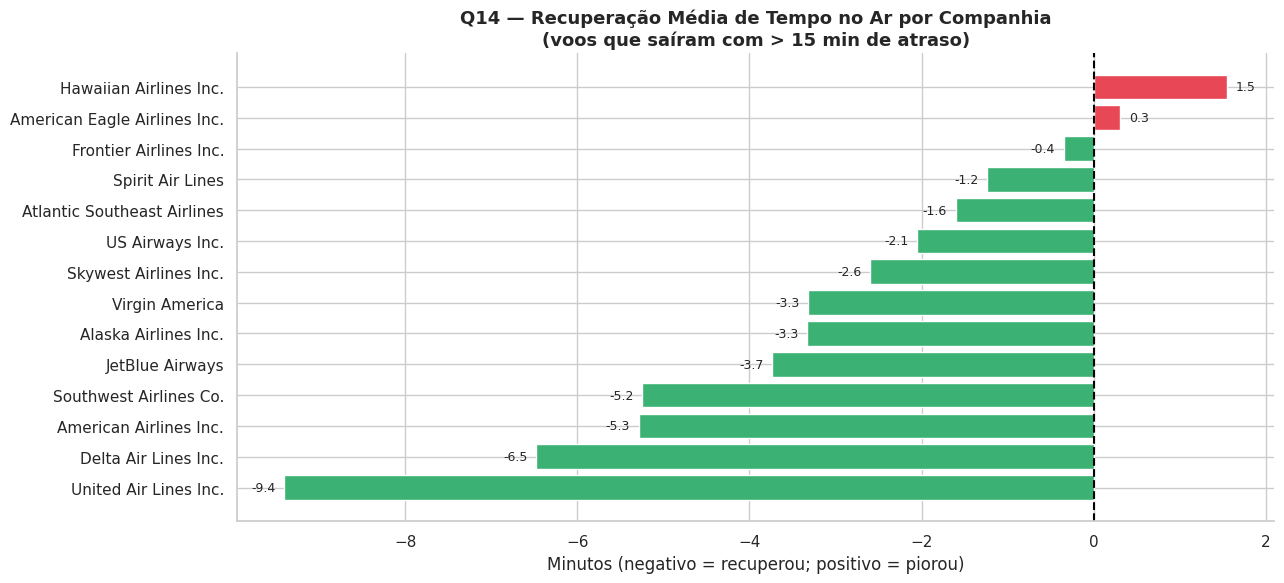

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q14 — Quais companhias conseguem recuperar mais tempo no ar?
# ══════════════════════════════════════════════════════════════════════════════
# Filtra voos que saíram atrasados (> 15 min) e mede quanto foi recuperado
q14 = (df_voos[df_voos['DEPARTURE_DELAY'] > 15]
       .groupby('AIRLINE_NAME')['DIFF_ATRASO']
       .mean()
       .sort_values())  # mais negativo = mais recuperação

fig, ax = plt.subplots(figsize=(13, 6))
cores_q14 = [COR_OK if v < 0 else COR_ALERTA for v in q14]
ax.barh(q14.index, q14.values, color=cores_q14, edgecolor='white')
ax.axvline(0, color='black', linestyle='--', lw=1.5)
ax.set_title('Q14 — Recuperação Média de Tempo no Ar por Companhia\n'
             '(voos que saíram com > 15 min de atraso)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Minutos (negativo = recuperou; positivo = piorou)')
for i, v in enumerate(q14.values):
    ax.text(v + 0.1 if v >= 0 else v - 0.1, i,
            f'{v:.1f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()


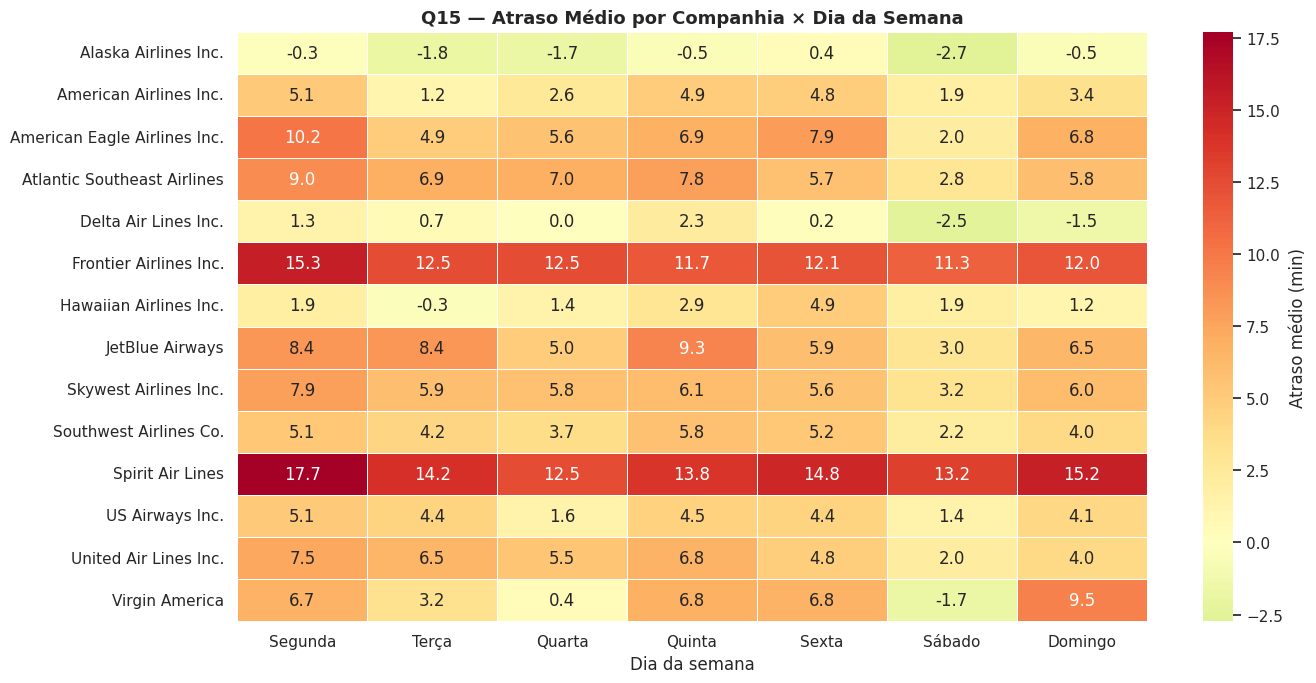

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Q15 — Como a combinação companhia + dia da semana afeta o atraso?
# ══════════════════════════════════════════════════════════════════════════════
q15 = (df_voos.groupby(['AIRLINE_NAME', 'DAY_OF_WEEK'])['ARRIVAL_DELAY']
       .mean()
       .unstack('DAY_OF_WEEK'))
q15.columns = dias_label

plt.figure(figsize=(14, 7))
sns.heatmap(q15, annot=True, fmt='.1f', cmap=CMAP_DIV,
            linewidths=0.5, cbar_kws={'label': 'Atraso médio (min)'},
            center=0)
plt.title('Q15 — Atraso Médio por Companhia × Dia da Semana', fontweight='bold', fontsize=13)
plt.xlabel('Dia da semana'); plt.ylabel('')
plt.tight_layout(); plt.show()


## 6. Análise Detalhada das Causas de Atraso


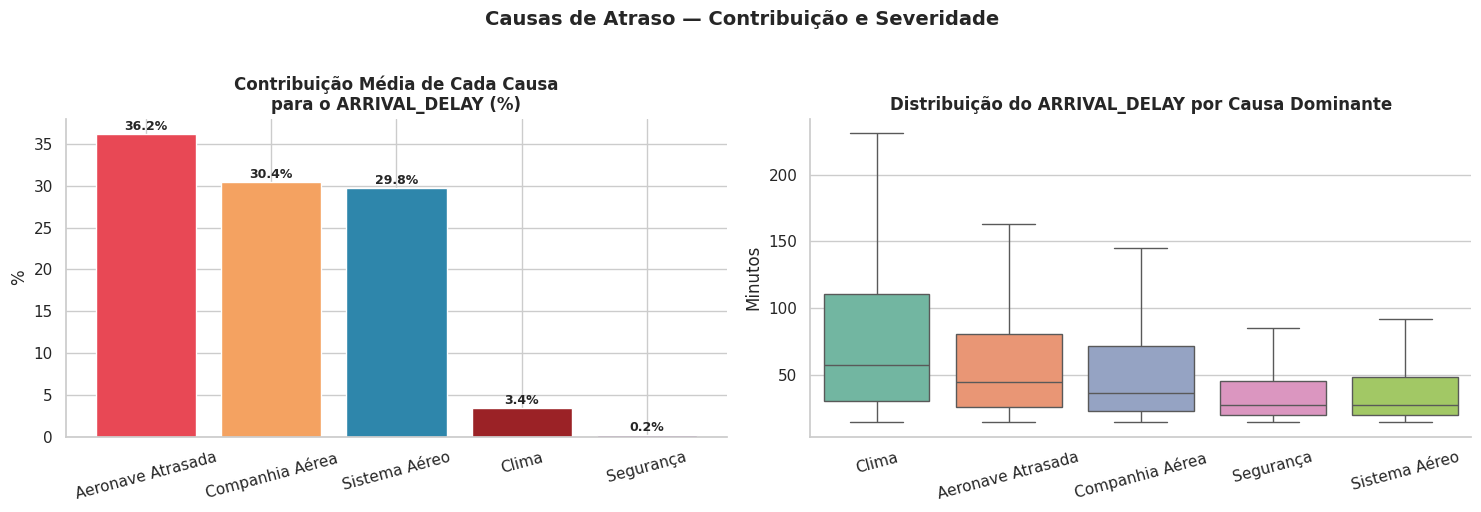

In [ ]:
# ── 6.1 Proporção de cada causa no ARRIVAL_DELAY ────────────────────────────
df_analise = df_voos[(df_voos['ARRIVAL_DELAY'] > 0) &
                     (df_voos[cols_motivo].sum(axis=1) > 0)].copy()

for col in cols_motivo:
    df_analise[f'PROP_{col}'] = df_analise[col] / df_analise['ARRIVAL_DELAY'].clip(lower=1)

props = df_analise[[f'PROP_{c}' for c in cols_motivo]].mean()
props.index = [labels_motivos[c] for c in cols_motivo]
props = props.sort_values(ascending=False)

df_analise['CAUSA_DOMINANTE'] = df_analise[cols_motivo].idxmax(axis=1).map(labels_motivos)
order = df_analise.groupby('CAUSA_DOMINANTE')['ARRIVAL_DELAY'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cores_prop = [COR_ALERTA, COR_NEUTRO, COR_PRINCIPAL, '#9B2226', '#6A0572']
axes[0].bar(props.index, props.values * 100, color=cores_prop, edgecolor='white')
axes[0].set_title('Contribuição Média de Cada Causa\npara o ARRIVAL_DELAY (%)', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(props.values):
    axes[0].text(i, v*100 + 0.5, f'{v*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

sns.boxplot(data=df_analise, x='CAUSA_DOMINANTE', y='ARRIVAL_DELAY',
            order=order, ax=axes[1], palette='Set2', showfliers=False)
axes[1].set_title('Distribuição do ARRIVAL_DELAY por Causa Dominante', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Minutos')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Causas de Atraso — Contribuição e Severidade', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


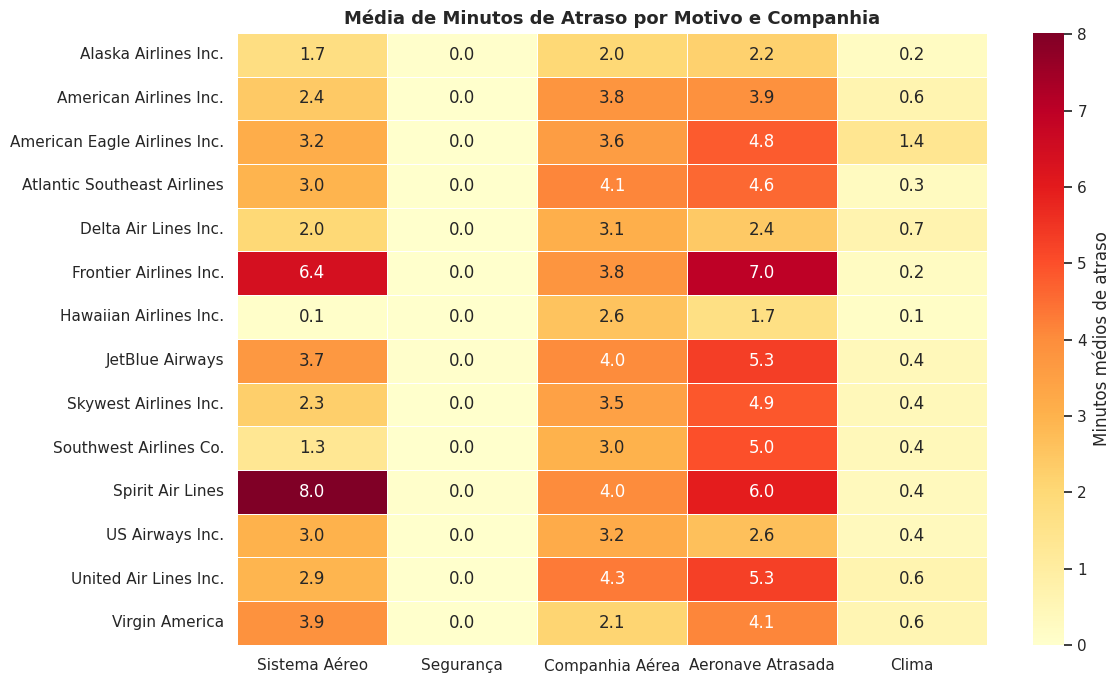

In [ ]:
# ── 6.2 Heatmap: motivos de atraso por companhia ────────────────────────────
motivo_por_cia = df_voos.groupby('AIRLINE_NAME')[cols_motivo].mean()
motivo_por_cia.columns = [labels_motivos[c] for c in motivo_por_cia.columns]

plt.figure(figsize=(12, 7))
sns.heatmap(motivo_por_cia, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Minutos médios de atraso'})
plt.title('Média de Minutos de Atraso por Motivo e Companhia', fontsize=13, fontweight='bold')
plt.xlabel(''); plt.ylabel('')
plt.tight_layout(); plt.show()


## 7. Modelagem Preditiva

Dois problemas serão modelados:

| Tipo | Pergunta | Variável alvo | Modelos |
|---|---|---|---|
| **Classificação** | O voo vai atrasar mais de 15 min? | `ATRASADO_FAA` (0/1) | Random Forest, Logistic Regression |
| **Regressão** | Quantos minutos o voo vai atrasar? | `ARRIVAL_DELAY` (contínuo) | Random Forest Regressor, Ridge |

> ⚠️ **Atenção ao vazamento de dados (data leakage):** variáveis como `DEPARTURE_DELAY`, `AIR_TIME`, `ELAPSED_TIME` e as colunas de motivo são conhecidas **apenas após a operação do voo**, portanto serão **excluídas** do conjunto de features de predição em produção. Para fins de análise exploratória e benchmarking interno, utilizaremos apenas variáveis disponíveis antes do voo.


In [ ]:
# ── 7.1 Preparação do dataset de modelagem ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (classification_report, confusion_matrix,
                              mean_absolute_error, r2_score, ConfusionMatrixDisplay)

# Features disponíveis ANTES do voo (sem leakage)
FEATURES_PRE_VOO = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'HORA',
    'AIRLINE_CODE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_TIME', 'DISTANCE'
]
TARGET_CLASS = 'ATRASADO_FAA'
TARGET_REG   = 'ARRIVAL_DELAY'

# Subconjunto sem nulos nas features e nos alvos
df_model = df_voos[FEATURES_PRE_VOO + [TARGET_CLASS, TARGET_REG]].dropna()

# Codificar variáveis categóricas
le_airline  = LabelEncoder()
le_origin   = LabelEncoder()
le_dest     = LabelEncoder()

df_model = df_model.copy()
df_model['AIRLINE_CODE']      = le_airline.fit_transform(df_model['AIRLINE_CODE'])
df_model['ORIGIN_AIRPORT']    = le_origin.fit_transform(df_model['ORIGIN_AIRPORT'])
df_model['DESTINATION_AIRPORT'] = le_dest.fit_transform(df_model['DESTINATION_AIRPORT'])

# Amostrar para agilizar (mude p/ None para usar tudo)
SAMPLE_SIZE = 200_000
df_model_s = df_model.sample(n=min(SAMPLE_SIZE, len(df_model)), random_state=42)

X = df_model_s[FEATURES_PRE_VOO]
y_class = df_model_s[TARGET_CLASS]
y_reg   = df_model_s[TARGET_REG]

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(f"✅ Treino: {len(X_train):,} amostras  |  Teste: {len(X_test):,} amostras")
print(f"   Proporção de atrasados no treino: {yc_train.mean()*100:.1f}%")


✅ Treino: 160,000 amostras  |  Teste: 40,000 amostras
   Proporção de atrasados no treino: 17.8%


  CLASSIFICAÇÃO — Random Forest
              precision    recall  f1-score   support

Não atrasado       0.88      0.64      0.74     32871
    Atrasado       0.27      0.61      0.38      7129

    accuracy                           0.64     40000
   macro avg       0.58      0.63      0.56     40000
weighted avg       0.78      0.64      0.68     40000



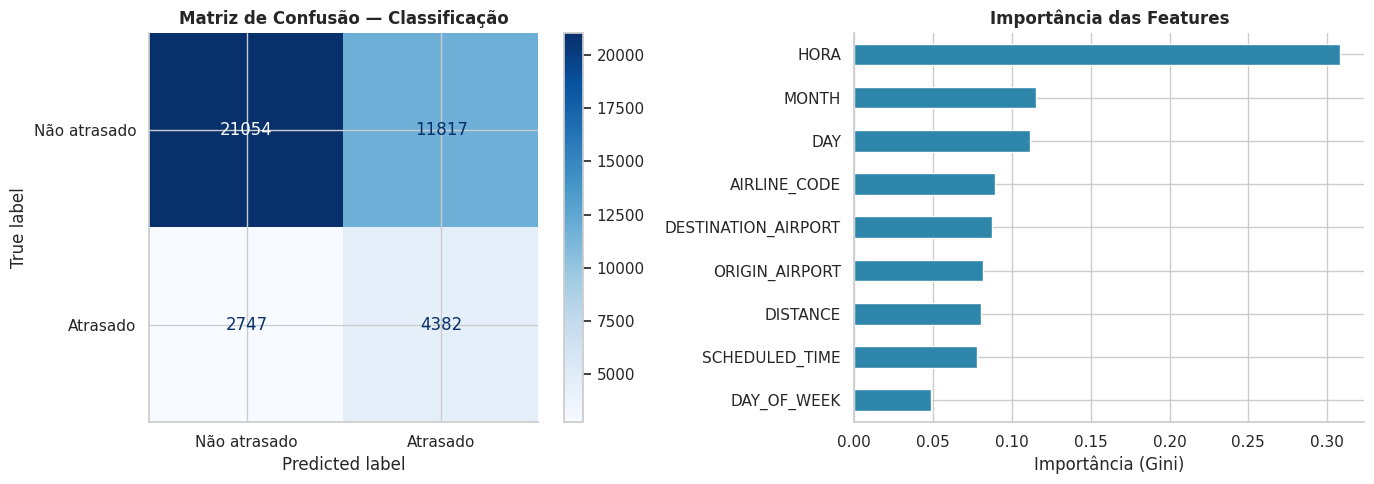

In [ ]:
# ── 7.2 Classificação — Random Forest ───────────────────────────────────────
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_clf.fit(X_train, yc_train)
yc_pred = rf_clf.predict(X_test)

print("=" * 55)
print("  CLASSIFICAÇÃO — Random Forest")
print("=" * 55)
print(classification_report(yc_test, yc_pred, target_names=['Não atrasado','Atrasado']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred,
    display_labels=['Não atrasado','Atrasado'], cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão — Classificação', fontweight='bold')

# Importância das features
importances = pd.Series(rf_clf.feature_importances_, index=FEATURES_PRE_VOO).sort_values()
importances.plot(kind='barh', ax=axes[1], color=COR_PRINCIPAL, edgecolor='white')
axes[1].set_title('Importância das Features', fontweight='bold')
axes[1].set_xlabel('Importância (Gini)')

plt.tight_layout(); plt.show()


  REGRESSÃO — Random Forest
  MAE  (erro médio absoluto) : 20.45 minutos
  R²   (variância explicada) : 0.0277


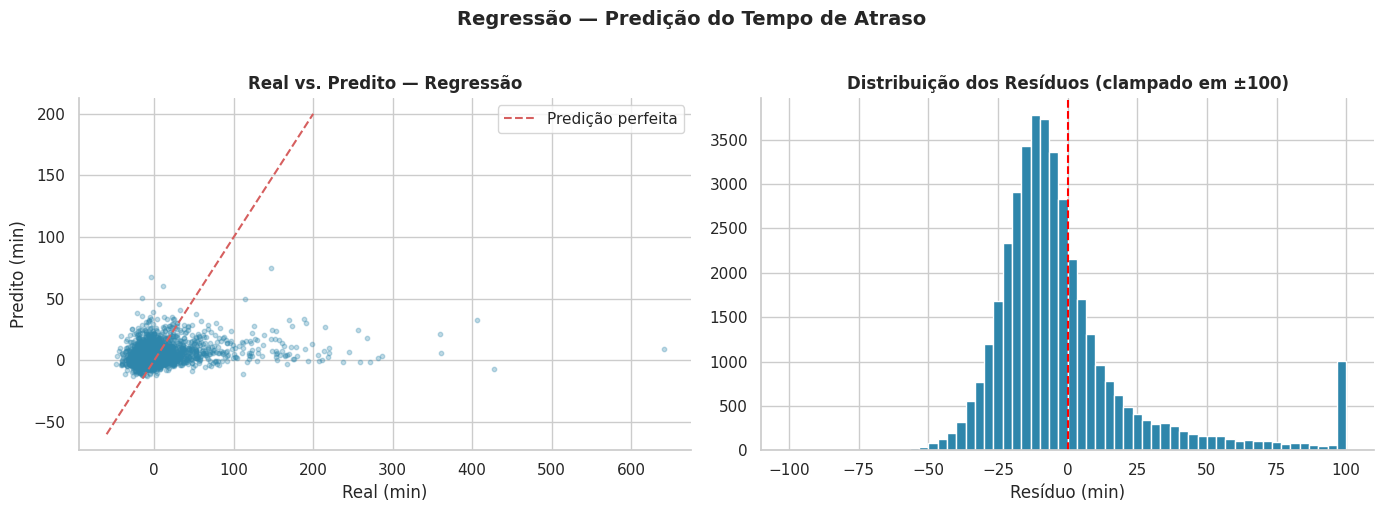

In [ ]:
# ── 7.3 Regressão — Random Forest ───────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, yr_train)
yr_pred = rf_reg.predict(X_test)

mae  = mean_absolute_error(yr_test, yr_pred)
r2   = r2_score(yr_test, yr_pred)

print("=" * 55)
print("  REGRESSÃO — Random Forest")
print("=" * 55)
print(f"  MAE  (erro médio absoluto) : {mae:.2f} minutos")
print(f"  R²   (variância explicada) : {r2:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predito vs Real (amostra)
amostra = np.random.choice(len(yr_test), size=min(3000, len(yr_test)), replace=False)
axes[0].scatter(yr_test.values[amostra], yr_pred[amostra],
                alpha=0.3, color=COR_PRINCIPAL, s=10)
lims = [max(yr_test.min(), -60), min(yr_test.max(), 200)]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Predição perfeita')
axes[0].set_xlabel('Real (min)'); axes[0].set_ylabel('Predito (min)')
axes[0].set_title('Real vs. Predito — Regressão', fontweight='bold')
axes[0].legend()

# Resíduos
residuos = yr_test.values - yr_pred
axes[1].hist(residuos.clip(-100, 100), bins=60, color=COR_PRINCIPAL, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Distribuição dos Resíduos (clampado em ±100)', fontweight='bold')
axes[1].set_xlabel('Resíduo (min)')

plt.suptitle('Regressão — Predição do Tempo de Atraso', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


In [ ]:
# ── 7.4 Comparação de modelos ────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression
lr_clf = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)
lr_clf.fit(X_train_sc, yc_train)
yc_pred_lr = lr_clf.predict(X_test_sc)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, yr_train)
yr_pred_ridge = ridge.predict(X_test_sc)

from sklearn.metrics import accuracy_score, f1_score

resultados = pd.DataFrame({
    'Modelo': ['Random Forest (Clf)', 'Logistic Regression',
               'Random Forest (Reg)', 'Ridge Regression'],
    'Métrica': ['F1-Score (macro)', 'F1-Score (macro)', 'MAE (min)', 'MAE (min)'],
    'Valor': [
        f1_score(yc_test, yc_pred, average='macro'),
        f1_score(yc_test, yc_pred_lr, average='macro'),
        mean_absolute_error(yr_test, yr_pred),
        mean_absolute_error(yr_test, yr_pred_ridge)
    ]
})

print("=" * 55)
print("  COMPARAÇÃO DE MODELOS")
print("=" * 55)
display(resultados.style
        .format({'Valor': '{:.4f}'})
        .background_gradient(subset=['Valor'], cmap='RdYlGn'))


  COMPARAÇÃO DE MODELOS


,Modelo,Métrica,Valor
0,Random Forest (Clf),F1-Score (macro),0.5593
1,Logistic Regression,F1-Score (macro),0.5169
2,Random Forest (Reg),MAE (min),20.4491
3,Ridge Regression,MAE (min),20.9096


## 8. Conclusões e Próximos Passos

### Principais Insights da Análise

| Dimensão | Descoberta |
|---|---|
| **Temporal** | Junho e Julho concentram os maiores atrasos; voos noturnos sofrem mais com o "efeito cascata" do dia |
| **Causas** | Atraso por aeronave anterior (*Late Aircraft*) é a causa mais frequente — reflexo do efeito cascata operacional |
| **Companhias** | Há variação significativa entre companhias; algumas conseguem recuperar tempo no ar de forma consistente |
| **Rotas** | Certas rotas regionais apresentam atrasos médios muito acima da média nacional |
| **Clima** | Cancelamentos por clima se concentram nos meses de inverno (Jan–Fev) e verão (Jun–Jul) |

### Limitações e Próximos Passos

1. **Enriquecimento com dados climáticos externos** — cruzar com dados reais de clima por aeroporto e data melhoraria muito a predição de atrasos por tempo
2. **Dados de mais anos** — o dataset cobre apenas 2015; modelos treinados em múltiplos anos seriam mais robustos a sazonalidades atípicas
3. **Modelos mais avançados** — XGBoost, LightGBM e redes neurais tendem a superar o Random Forest em datasets tabulares de grande volume

